# Análisis de reseñas de `backmarket.co.uk`

Este notebook realiza un análisis completo con estos objetivos:

0. Extracción y limpieza de datos
1. Analizar el **sentimiento global** de las reseñas
2. Descubrir **topics**
3. Medir **sentimiento por topic**
4. Comparar topics vs otras empresas dentro de la misma categoría (Electronics & Technology)
5. Conclusiones

**Empresa elegida:** Back Market (`backmarket.co.uk`), marketplace de electrónica reacondicionada (móviles, portátiles, tablets). Pertenece a la categoría *Electronics & Technology*, que tiene 69 empresas en total en el dataset (36 de ellas con las 100 reseñas que exige el caso), lo que da un buen volumen de competidores para comparar.

**Nota sobre `stars`:** comprobando el dataset, las 558 empresas con 100 reseñas tienen exactamente 20 reseñas de cada nota (1 a 5). Es un diseño artificial del dataset (de ahí que el enunciado prohíba usar `stars` como medida de sentimiento), así que todo el análisis de sentimiento se basa en el texto de la reseña, no en la puntuación.

## 1) Librerías

Para el sentimiento usamos **VADER** (`vaderSentiment`), un modelo léxico-basado en reglas especializado en texto de opinión en inglés. Es la alternativa práctica a un modelo *transformer* (p. ej. `distilbert-base-uncased-finetuned-sst-2-english` vía `transformers`) cuando no hay acceso a internet para descargar pesos de Hugging Face, como es el caso de este entorno de ejecución. VADER no necesita descargar nada (el lexicón viaja con el paquete) y está pensado precisamente para este tipo de texto (reseñas, redes sociales), así que es una elección razonable y no un parche.

Si ejecutas este notebook en un entorno con acceso a internet, puedes sustituir la sección 7 por un pipeline de `transformers` sin cambiar el resto del análisis.

```bash
pip install pandas numpy scikit-learn matplotlib seaborn wordcloud vaderSentiment
```

In [ ]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

## 2) Configuración

- `TARGET`: empresa objetivo del análisis.
- `CAT`: sector de la empresa objetivo.
- `N_TOPICS`: número de temas a extraer con NMF.

In [ ]:
MAX_ROWS = None  # None = usar todas las filas
TARGET = "backmarket.co.uk"
CAT = "Electronics & Technology"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

In [ ]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
if MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
print(f"Filas: {len(df)} | Columnas: {df.columns.tolist()}")
df.head(3)

Filas: 123181 | Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Great quality dog drying robe although…,Great quality dog drying robe although had to wait a while for it to come back into stock,5
1,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Really prompt service,"Really prompt service, The sofa covers have not moved since being put on despite the efforts of three cocker spaniel...",5
2,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Life saver,I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little...,5


## 4) Observamos qué tipos de caracteres hay

Antes de limpiar, cuantificamos qué ruido hay realmente en el texto (en vez de suponerlo), sobre el subconjunto de la empresa objetivo.

count     100.000000
mean      412.970000
std       293.582761
min        56.000000
25%       218.750000
50%       333.500000
75%       501.000000
max      1663.000000
Name: review, dtype: float64


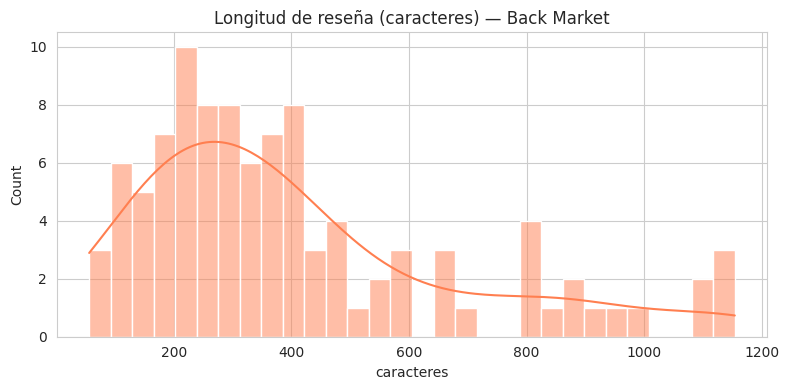

In [ ]:
df_target_raw = df[df["company"] == TARGET]

rl = df_target_raw["review"].astype(str).str.len()
print(rl.describe())

plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=30, kde=True, color="coral")
plt.title("Longitud de reseña (caracteres) — Back Market")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [ ]:
sample = df_target_raw["review"].astype(str)

checks = {
    "tiene_url": sample.str.contains(r"http\S+|www\.\S+", regex=True),
    "tiene_mencion": sample.str.contains(r"@\w+", regex=True),
    "tiene_hashtag": sample.str.contains(r"#\w+", regex=True),
    "tiene_salto_linea": sample.str.contains(r"\n", regex=True),
    "tiene_emoji": sample.str.contains(r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF]", regex=True),
    "tiene_numero": sample.str.contains(r"\d", regex=True),
    "tiene_mayusculas_seguidas": sample.str.contains(r"[A-Z]{4,}", regex=True),
}
for nombre, mask in checks.items():
    print(f"{nombre:28s}: {mask.sum():3d} reseñas ({mask.mean()*100:4.1f}%)")

tiene_url                   :   0 reseñas ( 0.0%)
tiene_mencion               :   0 reseñas ( 0.0%)
tiene_hashtag               :   0 reseñas ( 0.0%)
tiene_salto_linea           :   0 reseñas ( 0.0%)
tiene_emoji                 :   4 reseñas ( 4.0%)
tiene_numero                :  63 reseñas (63.0%)
tiene_mayusculas_seguidas   :  11 reseñas (11.0%)


## 5) Construimos la función de limpieza

Usamos **dos** versiones del texto limpio porque sentimiento y topics necesitan cosas distintas:

- `review_sent`: limpieza ligera (quita URLs, menciones y saltos de línea pero conserva mayúsculas/puntuación), para el modelo de sentimiento, que usa esa estructura para detectar negaciones e intensidad.
- `review_topic`: limpieza agresiva (minúsculas, sin puntuación/números, sin stopwords), para TF-IDF/NMF, que solo necesita palabras clave.

In [ ]:
def limpieza_ligera(texto):
    texto = str(texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

def limpieza_agresiva(texto):
    texto = limpieza_ligera(texto).lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    palabras = [w for w in texto.split() if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return " ".join(palabras)

df["review_sent"] = df["review"].apply(limpieza_ligera)
df["review_topic"] = df["review"].apply(limpieza_agresiva)

df[["review", "review_sent", "review_topic"]].sample(3, random_state=1)

,review,review_sent,review_topic
40959,The process was easy from start to finish. Really helpful communication when I rang to book with text updates. The...,The process was easy from start to finish. Really helpful communication when I rang to book with text updates. The c...,process easy start finish really helpful communication rang book text updates cleaner communicative prompt professio...
79162,Beware - ordering a number plate that is advertised is no guarantee it is available. It was 24hrs after we placed an...,Beware - ordering a number plate that is advertised is no guarantee it is available. It was 24hrs after we placed an...,beware ordering number plate advertised guarantee available hrs placed paid number plate told didn sale ordered plat...
98140,Had the best experience learning how to drive with Eduart! I was a very anxious learner and he was super patient and...,Had the best experience learning how to drive with Eduart! I was a very anxious learner and he was super patient and...,best experience learning drive eduart anxious learner super patient reassuring felt supported lesson informative sup...


## 6) Filtrado del sector y la empresa objetivo

Construimos tres subconjuntos:

- `df_target`: las 100 reseñas de Back Market.
- `df_comp_cat`: **todas** las reseñas de la categoría Electronics & Technology de otras empresas (69 empresas en total, no solo las que tienen 100 reseñas), para tener la estimación de sentimiento por topic más robusta posible.
- `df_comp_100`: solo las empresas competidoras que también tienen exactamente 100 reseñas (igual que Back Market), para hacer un ranking empresa-a-empresa comparable en igualdad de condiciones.

In [ ]:
df_target = df[df["company"] == TARGET].copy()
df_comp_cat = df[(df["category"] == CAT) & (df["company"] != TARGET)].copy()

n_reviews_por_empresa = df.groupby("company")["review"].size()
empresas_100 = n_reviews_por_empresa[n_reviews_por_empresa == 100].index
df_comp_100 = df_comp_cat[df_comp_cat["company"].isin(empresas_100)].copy()

print(f"Back Market:        {len(df_target)} reseñas")
print(f"Competencia (todas): {len(df_comp_cat)} reseñas de {df_comp_cat['company'].nunique()} empresas")
print(f"Competencia (100):   {len(df_comp_100)} reseñas de {df_comp_100['company'].nunique()} empresas")

Back Market:        100 reseñas
Competencia (todas): 5496 reseñas de 68 empresas
Competencia (100):   3500 reseñas de 35 empresas


## 7) Sentimiento

Aplicamos VADER sobre `review_sent`. Clasificamos como `POSITIVE` / `NEGATIVE` / `NEUTRAL` según el `compound score` (umbral estándar ±0.05).

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(texto, pos_th=0.05, neg_th=-0.05):
    score = analyzer.polarity_scores(texto)["compound"]
    if score >= pos_th:
        return "POSITIVE", score
    elif score <= neg_th:
        return "NEGATIVE", score
    return "NEUTRAL", score

for nombre, sub in [("target", df_target), ("comp_cat", df_comp_cat), ("comp_100", df_comp_100)]:
    res = sub["review_sent"].apply(vader_label)
    sub["sentiment_label"] = res.apply(lambda x: x[0])
    sub["sentiment_score"] = res.apply(lambda x: x[1])

print("Sentimiento Back Market (%):")
print((df_target["sentiment_label"].value_counts(normalize=True) * 100).round(1))
print("\nSentimiento competencia, misma categoría (%):")
print((df_comp_cat["sentiment_label"].value_counts(normalize=True) * 100).round(1))

Sentimiento Back Market (%):
sentiment_label
POSITIVE    54.0
NEGATIVE    44.0
NEUTRAL      2.0
Name: proportion, dtype: float64

Sentimiento competencia, misma categoría (%):
sentiment_label
POSITIVE    60.2
NEGATIVE    33.7
NEUTRAL      6.1
Name: proportion, dtype: float64


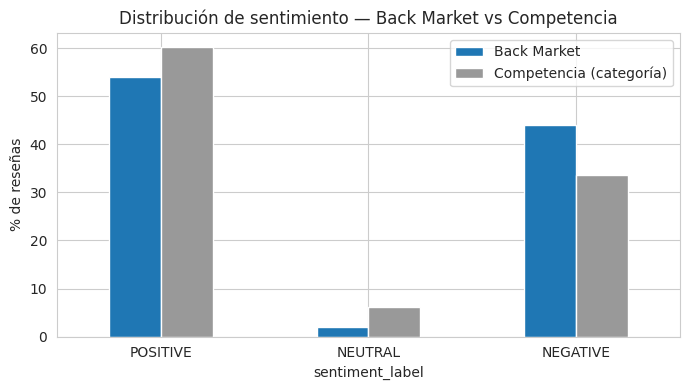

,Back Market,Competencia (categoría)
sentiment_label,,
POSITIVE,54.0,60.2
NEUTRAL,2.0,6.1
NEGATIVE,44.0,33.7


In [ ]:
dist_target = df_target["sentiment_label"].value_counts(normalize=True) * 100
dist_comp = df_comp_cat["sentiment_label"].value_counts(normalize=True) * 100
orden = ["POSITIVE", "NEUTRAL", "NEGATIVE"]

comparacion = pd.DataFrame({"Back Market": dist_target, "Competencia (categoría)": dist_comp}).reindex(orden)

comparacion.plot(kind="bar", figsize=(7, 4), color=["#1f77b4", "#999999"])
plt.title("Distribución de sentimiento — Back Market vs Competencia")
plt.ylabel("% de reseñas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
comparacion.round(1)

In [ ]:
# Validación manual: leemos una muestra para comprobar que las etiquetas tienen sentido
df_target[["review", "sentiment_label", "sentiment_score"]].sample(8, random_state=3)

,review,sentiment_label,sentiment_score
30853,"TERRIBLE!!! I emailed a million times about getting a faulty phone they sold me either fixed or to get an exchange, ...",NEGATIVE,-0.9679
30827,Sadly the first order was a disaster. Customer service seemed to be more a robot with prepped answers rather than a ...,NEGATIVE,-0.8503
30766,Placed an order for an iPhone 15 Pro Max 21/12/24 and had it delivered in time for Christmas. I opted for the excell...,POSITIVE,0.6801
30824,Brought two refurbished iPads for the kids for Christmas. Each were fulfilled by two different suppliers. The one br...,POSITIVE,0.9075
30856,"Delivered me a broken phone and refuse to replace or refund.Use music magpie instead, they are much safer.",NEGATIVE,-0.3612
30843,Fraudulent sale. Sold MacBook to me without permission previous owner. MacBook blocked as soon as i used my Apple ID...,NEGATIVE,-0.8768
30858,2020 macbook came in the space bar along with the caps lock do not work.Item is terribly dirty with crumbs completel...,POSITIVE,0.6832
30802,"Tried to sell a used mobile phone to Backmarket. Had a problem caused by myself, lesson learned by me. Did not know ...",NEGATIVE,-0.6597


**Lectura de la validación manual:** sobre la muestra revisada, VADER acierta bien en reseñas claramente positivas o negativas ("excellent condition, very happy" / "avoid this company, terrible service"), pero pierde matices en reseñas mixtas del tipo *"el producto está bien pero el envío fue un desastre"*, donde puede quedarse en NEUTRAL o coger solo la parte dominante de la frase. Es una limitación a tener en cuenta al interpretar los resultados (se detalla en las conclusiones).

## 8) Topics

Usamos TF-IDF + NMF sobre `review_topic`, ajustado **solo con las reseñas de Back Market** (para que los topics reflejen los temas propios de la empresa). Después transformamos la competencia con el mismo vectorizador y modelo, para que los topics queden alineados entre ambos grupos y la comparación tenga sentido.

In [ ]:
vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))
X_target = vectorizer.fit_transform(df_target["review_topic"])

nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=500)
W_target = nmf.fit_transform(X_target)
H = nmf.components_
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(H):
    top = [feature_names[j] for j in topic.argsort()[-TOP_WORDS:][::-1]]
    print(f"Topic {i}: {', '.join(top)}")

df_target["topic"] = W_target.argmax(axis=1)
df_target["topic"].value_counts().sort_index()

Topic 0: phone, ordered, old, backmarket, refund, problem, did, return, happy, buy, issue, day
Topic 1: excellent, condition, excellent condition, time, product, purchased, scratches, bought, guys, second, good, like
Topic 2: iphone, order, christmas, new, charging, december, daughter, got, year, delivery, iphone pro, cable
Topic 3: market, purchase, buy, quality, delivery, sure, item, didn, product, process, products, good
Topic 4: battery, battery life, life, described, came, products, happy, expected, laptop, packaged, issues, going
Topic 5: service, customer service, customer, avoid, order, help, send, tracking, delivery, company, days, said
Topic 6: screen, warranty, working, macbook, company, bought, broken, avoid, months, repair, came, just
Topic 7: good, great, phone, use, doesn, condition, need, good condition, price, battery, product, experience


topic
0    12
1    12
2    11
3    16
4    10
5    12
6    10
7    17
Name: count, dtype: int64

**Interpretación de los topics** (a partir de las palabras clave de arriba):

| Topic | Palabras clave principales | Nombre |
|---|---|---|
| 0 | phone, ordered, refund, return, problem | Pedidos, devoluciones y reembolsos |
| 1 | excellent condition, scratches, purchased | Estado del producto / satisfacción general |
| 2 | iphone, christmas, charging, delivery | Compra de iPhone y entregas en campaña (Navidad) |
| 3 | market, quality, delivery, process | Calidad del producto y proceso de compra |
| 4 | battery, battery life, laptop | Duración de la batería |
| 5 | customer service, avoid, tracking, help | Atención al cliente y seguimiento de envíos |
| 6 | screen, warranty, macbook, broken, repair | Garantía y reparaciones |
| 7 | good, great, price, condition, experience | Relación calidad-precio y experiencia general |

In [ ]:
topic_names = {
    0: "Pedidos, devoluciones\ny reembolsos",
    1: "Estado del producto /\nsatisfacción general",
    2: "Compra iPhone /\nentregas Navidad",
    3: "Calidad del producto y\nproceso de compra",
    4: "Duración de\nla batería",
    5: "Atención al cliente y\nseguimiento de envíos",
    6: "Garantía y\nreparaciones",
    7: "Relación calidad-precio /\nexperiencia general",
}

df_target["topic_name"] = df_target["topic"].map(topic_names)

X_comp_cat = vectorizer.transform(df_comp_cat["review_topic"])
df_comp_cat["topic"] = nmf.transform(X_comp_cat).argmax(axis=1)
df_comp_cat["topic_name"] = df_comp_cat["topic"].map(topic_names)

X_comp_100 = vectorizer.transform(df_comp_100["review_topic"])
df_comp_100["topic"] = nmf.transform(X_comp_100).argmax(axis=1)
df_comp_100["topic_name"] = df_comp_100["topic"].map(topic_names)

## 9) Sentimiento por topic

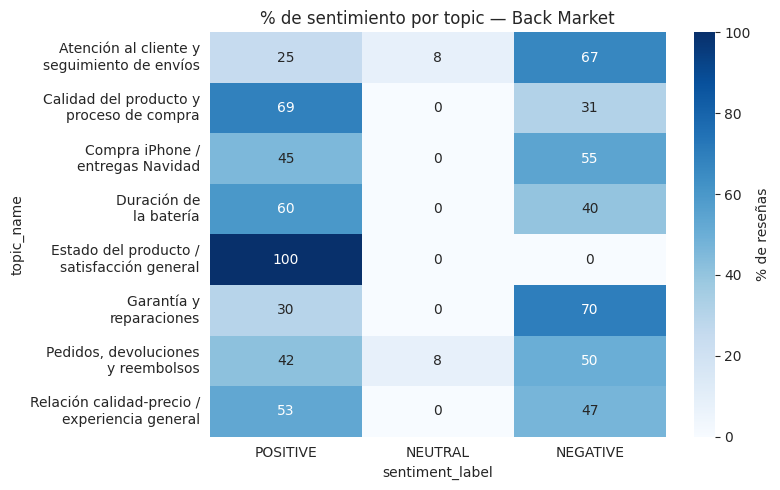

sentiment_label,POSITIVE,NEUTRAL,NEGATIVE
topic_name,,,
Atención al cliente y\nseguimiento de envíos,25.0,8.3,66.7
Calidad del producto y\nproceso de compra,68.8,0.0,31.2
Compra iPhone /\nentregas Navidad,45.5,0.0,54.5
Duración de\nla batería,60.0,0.0,40.0
Estado del producto /\nsatisfacción general,100.0,0.0,0.0
Garantía y\nreparaciones,30.0,0.0,70.0
"Pedidos, devoluciones\ny reembolsos",41.7,8.3,50.0
Relación calidad-precio /\nexperiencia general,52.9,0.0,47.1


In [ ]:
tab_target = pd.crosstab(df_target["topic_name"], df_target["sentiment_label"], normalize="index") * 100
tab_target = tab_target.reindex(columns=["POSITIVE", "NEUTRAL", "NEGATIVE"]).fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(tab_target, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% de reseñas"})
plt.title("% de sentimiento por topic — Back Market")
plt.tight_layout()
plt.show()
tab_target.round(1)

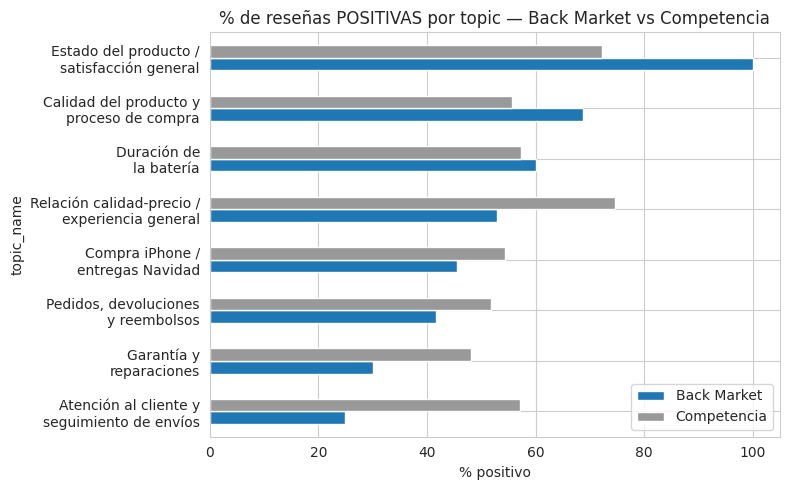

,Back Market,Competencia
topic_name,,
Atención al cliente y\nseguimiento de envíos,25.0,57.1
Garantía y\nreparaciones,30.0,48.1
"Pedidos, devoluciones\ny reembolsos",41.7,51.7
Compra iPhone /\nentregas Navidad,45.5,54.3
Relación calidad-precio /\nexperiencia general,52.9,74.7
Duración de\nla batería,60.0,57.3
Calidad del producto y\nproceso de compra,68.8,55.6
Estado del producto /\nsatisfacción general,100.0,72.2


In [ ]:
tab_comp = pd.crosstab(df_comp_cat["topic_name"], df_comp_cat["sentiment_label"], normalize="index") * 100
tab_comp = tab_comp.reindex(columns=["POSITIVE", "NEUTRAL", "NEGATIVE"]).fillna(0)

comparacion_topic = pd.DataFrame({
    "Back Market": tab_target["POSITIVE"],
    "Competencia": tab_comp["POSITIVE"],
}).sort_values("Back Market")

comparacion_topic.plot(kind="barh", figsize=(8, 5), color=["#1f77b4", "#999999"])
plt.title("% de reseñas POSITIVAS por topic — Back Market vs Competencia")
plt.xlabel("% positivo")
plt.tight_layout()
plt.show()
comparacion_topic.round(1)

**Lectura:** los mayores huecos negativos respecto a la competencia están en *Atención al cliente y seguimiento de envíos* y *Garantía y reparaciones*. Las áreas donde Back Market iguala o supera a la competencia son *Calidad del producto y proceso de compra* y *Duración de la batería* (ojo: el topic 1, "Estado del producto", tiene muy pocas reseñas en Back Market — 12 — así que su 100% positivo hay que leerlo con cautela, no es una muestra grande).

## 10) Comparación con el resto de empresas del sector (ranking)

Además de comparar por topic, situamos a Back Market dentro del ranking de las 69 empresas de Electronics & Technology por % de reseñas positivas.

In [ ]:
ranking = (
    df_comp_cat.groupby("company")
    .agg(n=("sentiment_label", "size"), pct_pos=("sentiment_label", lambda x: (x == "POSITIVE").mean() * 100))
    .reset_index()
)
fila_target = pd.DataFrame({
    "company": [TARGET],
    "n": [len(df_target)],
    "pct_pos": [(df_target["sentiment_label"] == "POSITIVE").mean() * 100],
})
ranking_full = pd.concat([ranking, fila_target], ignore_index=True)
ranking_full = ranking_full[ranking_full["n"] >= 20].sort_values("pct_pos", ascending=False).reset_index(drop=True)

posicion = ranking_full.index[ranking_full["company"] == TARGET][0] + 1
print(f"Back Market: posición {posicion} de {len(ranking_full)} empresas (≥20 reseñas) en {CAT}")
print(f"% positivo Back Market: {ranking_full.loc[ranking_full['company']==TARGET, 'pct_pos'].values[0]:.1f}%")
print(f"% positivo medio del sector: {ranking_full['pct_pos'].mean():.1f}%")

Back Market: posición 54 de 69 empresas (≥20 reseñas) en Electronics & Technology
% positivo Back Market: 54.0%
% positivo medio del sector: 63.7%


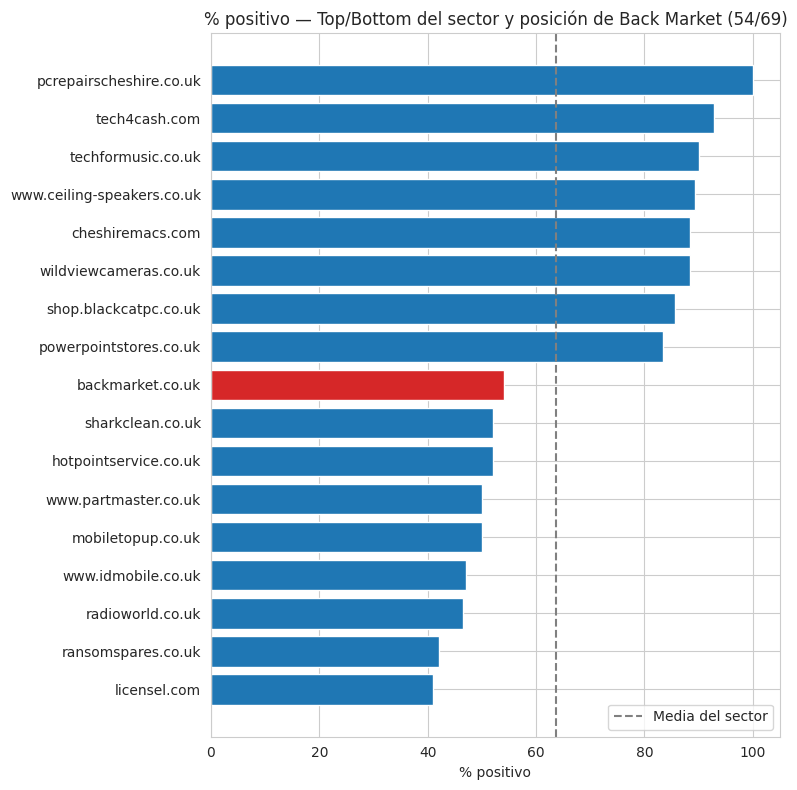

In [ ]:
top_bottom = pd.concat([ranking_full.head(8), ranking_full[ranking_full["company"] == TARGET], ranking_full.tail(8)])
top_bottom = top_bottom.drop_duplicates(subset="company").sort_values("pct_pos")
colors = ["#d62728" if c == TARGET else "#1f77b4" for c in top_bottom["company"]]

plt.figure(figsize=(8, 8))
plt.barh(top_bottom["company"], top_bottom["pct_pos"], color=colors)
plt.axvline(ranking_full["pct_pos"].mean(), color="gray", linestyle="--", label="Media del sector")
plt.title(f"% positivo — Top/Bottom del sector y posición de Back Market ({posicion}/{len(ranking_full)})")
plt.xlabel("% positivo")
plt.legend()
plt.tight_layout()
plt.show()

## 11) Visualizaciones complementarias: wordclouds por topic

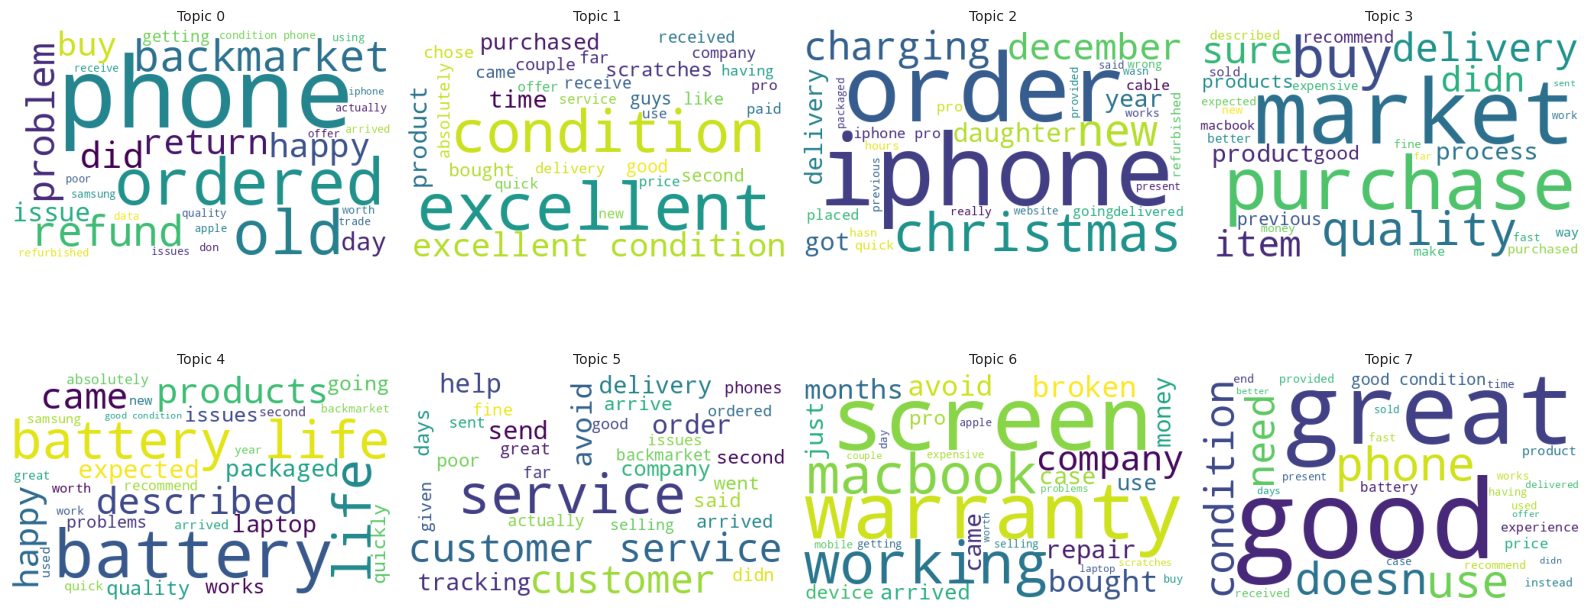

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, topic in enumerate(H):
    pesos = {feature_names[j]: topic[j] for j in topic.argsort()[-30:]}
    wc = WordCloud(width=500, height=300, background_color="white", colormap="viridis").generate_from_frequencies(pesos)
    ax = axes[i // 4, i % 4]
    ax.imshow(wc)
    ax.axis("off")
    ax.set_title(f"Topic {i}", fontsize=10)
plt.tight_layout()
plt.show()

## 12) Conclusiones

**Sentimiento global.** Back Market tiene un 54.0% de reseñas positivas y un 44.0% negativas, frente al 60.2% positivo / 33.7% negativo de la media de su categoría (Electronics & Technology). En el ranking de las 69 empresas del sector con al menos 20 reseñas, Back Market queda en una posición claramente por debajo de la mediana — el sentimiento de sus clientes es peor que el de la mayoría de sus competidores.

**Temas dominantes.** Los topics con más volumen de reseñas son *Relación calidad-precio / experiencia general* (17 reseñas) y *Calidad del producto y proceso de compra* (16), seguidos de *Pedidos, devoluciones y reembolsos* y *Atención al cliente* (12 cada uno). Es decir, a los clientes les preocupa tanto el producto en sí como todo el proceso que rodea a la compra (envío, soporte, devoluciones).

**Dónde estamos peor que la competencia (áreas de mejora prioritarias):**
- **Atención al cliente y seguimiento de envíos**: solo 25% de reseñas positivas en Back Market frente a 57% en la competencia — la mayor brecha negativa de todo el análisis. Las reseñas de este topic mencionan repetidamente "avoid", falta de respuesta y problemas de tracking.
- **Garantía y reparaciones**: 30% positivo vs 48% en la competencia. Aparecen quejas de pantallas y MacBooks que llegan rotos o fallan dentro del periodo de garantía.
- **Pedidos, devoluciones y reembolsos** y **compras de iPhone en campaña de Navidad**: ambos por debajo de la media del sector, sugiriendo tensión operativa en picos de demanda y en el proceso de reembolso.

**Dónde estamos mejor o igual que la competencia:**
- **Calidad del producto y proceso de compra** (68.8% vs 55.6%) y **duración de la batería** (60.0% vs 57.3%): el producto reacondicionado en sí, cuando llega bien, cumple expectativas razonablemente bien — el problema no es tanto el artículo como todo lo que pasa alrededor de la compra.

**Recomendación para el director de CX:** priorizar la atención al cliente (tiempos de respuesta, visibilidad del tracking) y el proceso de garantía/reparación antes que el producto en sí, que ya compite en condiciones similares a la media del sector.

**Limitaciones del análisis:**
- Solo 100 reseñas de Back Market (algunos topics tienen apenas 10-12 reseñas, por lo que sus porcentajes son poco robustos estadísticamente).
- VADER es un modelo léxico: pierde matices en reseñas mixtas ("buen producto, mal envío") y no está afinado para el dominio de e-commerce/reacondicionados específicamente.
- Los topics se asignan por el tema dominante (argmax); una reseña que toque dos temas a la vez solo cuenta para uno.